# Part 7: Explainability

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay

from autogluon.tabular import TabularPredictor

# libraries for advanced explainability
import shap
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

In [2]:
# 1) Load RAW data for AutoGluon
VAL_PATH   = r"C:\Users\Hzaab\Desktop\MLSD project\data\preprocessed\val_unprocessed.parquet"

val_raw= pd.read_parquet(VAL_PATH)


In [5]:
# AutoGluon feature importance expects the original feature columns, not the processed parquet version.
train_raw = val_raw

# Apply the same log transform used by the team preprocessing
log_cols = ["#follows", "#followers", "description length", "#posts"]
for col in log_cols:
    train_raw[col] = np.log1p(train_raw[col])

# Split exactly like the team
X_raw = train_raw.drop(columns=["fake"])
y_raw = train_raw["fake"]

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=10
)

# Validation frame for AutoGluon feature importance
val_raw = X_val_raw.copy()
val_raw["fake"] = y_val_raw.values



In [6]:
# 2) Load processed data for model-specific methods

# These are useful for SHAP / PDP / InterpretML on a standalone model
train_processed = pd.read_parquet(r"C:\Users\Hzaab\Desktop\MLSD project\data\preprocessed\train_processed.parquet")
val_processed = pd.read_parquet(r"C:\Users\Hzaab\Desktop\MLSD project\data\preprocessed\val_processed.parquet")

X_train_proc = train_processed.drop(columns=["fake"])
y_train_proc = train_processed["fake"]

X_val_proc = val_processed.drop(columns=["fake"])
y_val_proc = val_processed["fake"]


In [8]:
# 3) Load AutoGluon predictor
MODEL_PATH = r"C:\Users\Hzaab\Desktop\MLSD project\exports\autogluon_team"
predictor = TabularPredictor.load(MODEL_PATH)

# Best AutoGluon inference model
best_model_name = predictor.model_best
print("AutoGluon best model:", best_model_name)


AutoGluon best model: WeightedEnsemble_L3


## Part 7.1: Feature Importance
### 7.1.1 Autogluon feature importance



Top 10 AutoGluon Feature Importance Results:
                      importance    stddev   p_value  n  p99_high   p99_low
profile pic             0.081130  0.010062  0.000028  5  0.101847  0.060413
nums/length username    0.063660  0.005872  0.000009  5  0.075750  0.051570
nums/length fullname    0.008710  0.002905  0.001288  5  0.014691  0.002729
fullname words          0.004605  0.001895  0.002782  5  0.008507  0.000703
#posts                  0.004020  0.002129  0.006729  5  0.008404 -0.000364
external URL            0.001870  0.000736  0.002364  5  0.003385  0.000355
private                 0.001500  0.002292  0.108635  5  0.006220 -0.003220
#followers              0.001195  0.005822  0.335035  5  0.013182 -0.010792
description length      0.001090  0.001150  0.050742  5  0.003459 -0.001279
#follows                0.000035  0.000276  0.395583  5  0.000604 -0.000534


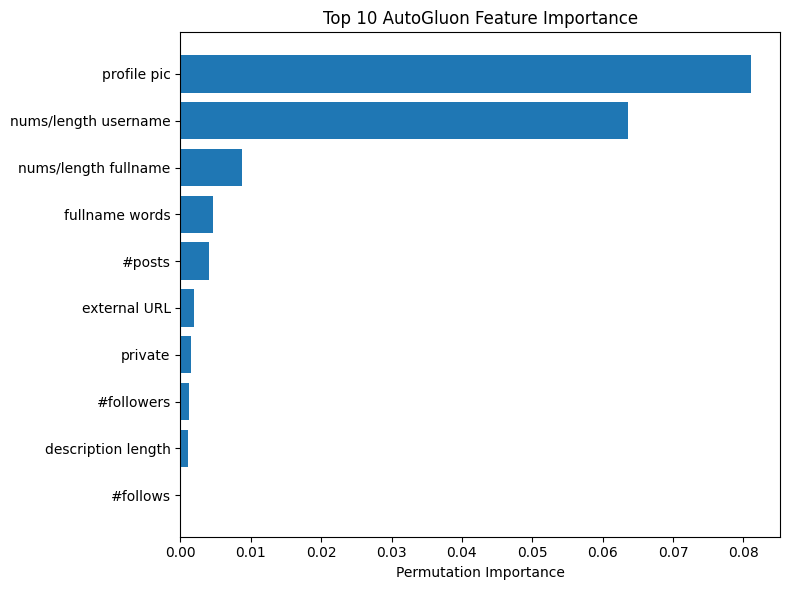

In [5]:
# AutoGluon computes permutation feature importance.
importance_df = predictor.feature_importance(val_raw)

print("\nTop 10 AutoGluon Feature Importance Results:")
print(importance_df.head(10))

# Plot top 10
top10_importance = importance_df.head(10).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top10_importance.index, top10_importance["importance"])
plt.xlabel("Permutation Importance")
plt.title("Top 10 AutoGluon Feature Importance")
plt.tight_layout()
plt.show()


## Part 7.2: Advanced Explainability

### 7.2.1 SHAP

In [6]:
from lightgbm import LGBMClassifier

model_shap = LGBMClassifier(random_state=10)
model_shap.fit(X_train_proc, y_train_proc)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 400, number of negative: 1600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1251
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


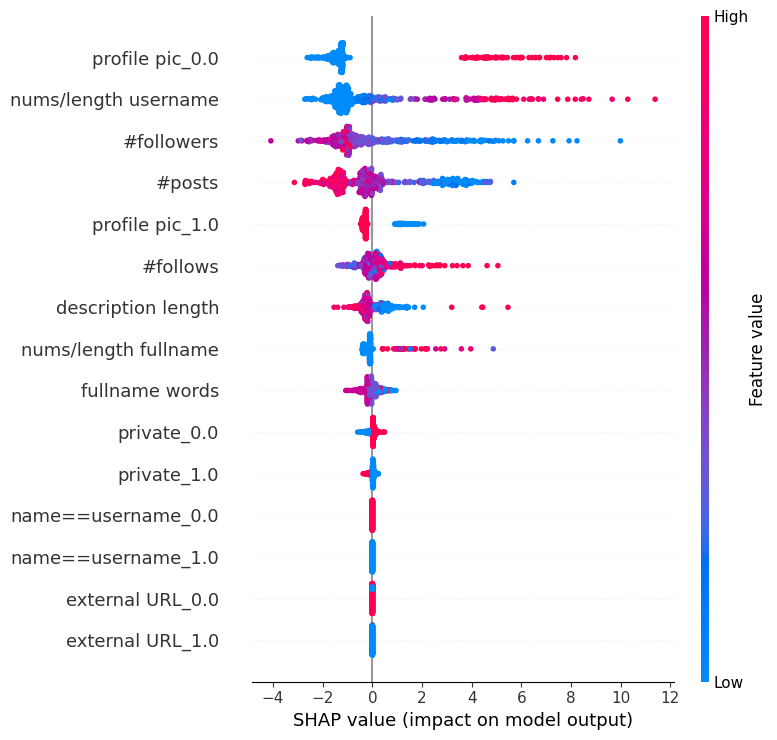

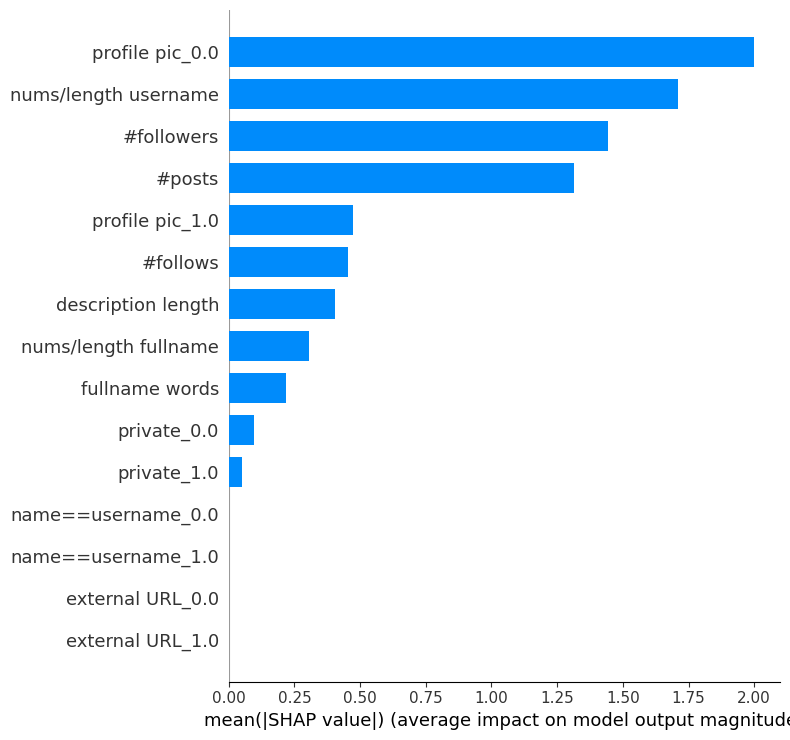

In [ ]:
# SHAP
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_val_proc)

# summary plot
shap.summary_plot(shap_values, X_val_proc)

# optional bar plot
shap.summary_plot(shap_values, X_val_proc, plot_type="bar")

###  7.2.2 Partial Dependence Plots

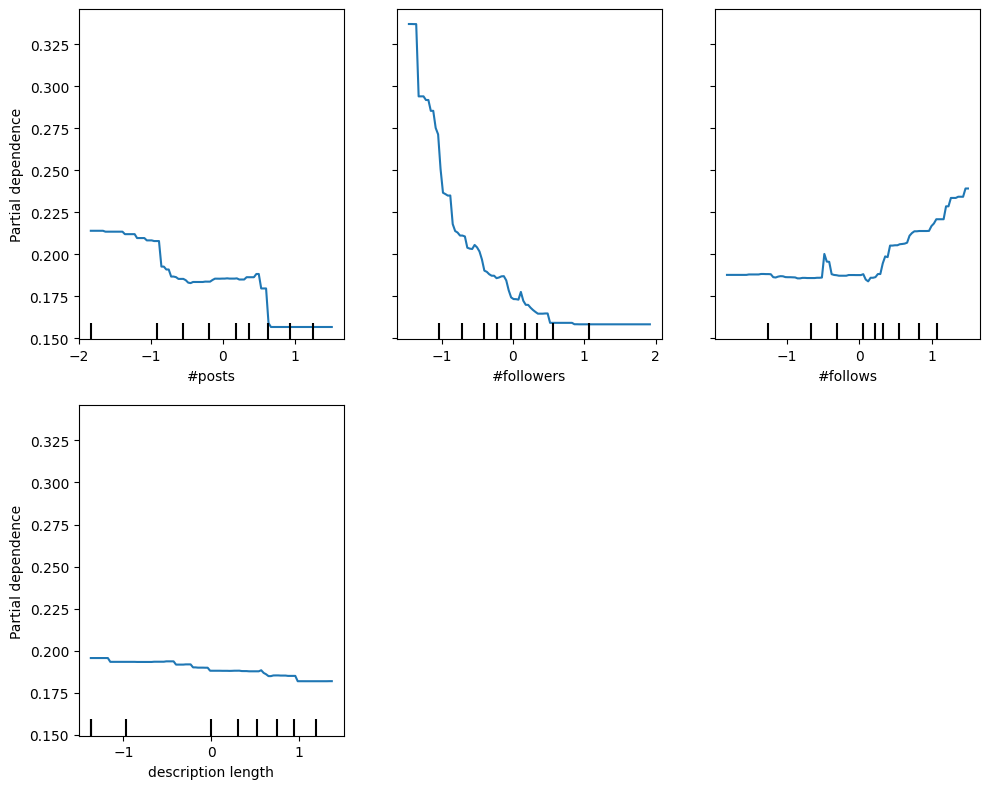

In [8]:
# Partial Dependence Plots
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

top_pdp_features = ["#posts", "#followers", "#follows", "description length"]

fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(
    model_shap,
    X_val_proc,
    features=top_pdp_features,
    ax=ax
)
plt.tight_layout()
plt.show()

###  7.2.3 InterpretML

In [9]:
# InterpretML
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

ebm = ExplainableBoostingClassifier(random_state=10)
ebm.fit(X_train_proc, y_train_proc)

# global explanation
ebm_global = ebm.explain_global()
show(ebm_global)


<!-- http://127.0.0.1:7001/2226205350880/ -->